# Explicabilidade via LLM Ollama com Contexto XAI (SHAP + LIME) — Multi-turn (Run 5)

Re-execução apenas com os modelos que produziram resultados úteis (gpt-oss:20b e qwen3:30b), com timeout aumentado.

In [1]:
# Importação de todas as bibliotecas que serão utilizadas
import pandas as pd
import numpy as np
import json
import time
import shap
import lime
from lime import lime_tabular
from openai import OpenAI
import httpx
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [ ]:
# ==========================
# CONFIGURAÇÃO DO OLLAMA
# ==========================
OLLAMA_BASE_URL = "http://localhost:11434/v1"
REQUEST_TIMEOUT = 900.0  # 15 minutos por request

# Modelos a serem consultados
models = [
    {"name": "glm-4.7-flash:latest",  "size": "medium"},
    {"name": "qwen3:14b",              "size": "medium"},
    {"name": "gpt-oss:20b",            "size": "medium"},
    {"name": "qwen3:30b",              "size": "large"},
]

# Leitura e Pre-processamento dos Dados

In [3]:
# Define o dataset que será utilizado
df = pd.read_csv("./Network_logs.csv")

In [4]:
# Cria uma cópia do dataset original
networkData = df.copy()

# Descarta as features IP de Origem/Destino (alta cardinalidade) e Intrusion (evitar overfitting)
networkData.drop(['Source_IP', 'Destination_IP', 'Intrusion'], axis=1, inplace=True)
networkData.head(5)

,Port,Request_Type,Protocol,Payload_Size,User_Agent,Status,Scan_Type
0,80,FTP,UDP,2369,curl/7.68.0,Success,Normal
1,135,SMTP,UDP,1536,Wget/1.20.3,Failure,BotAttack
2,21,SMTP,TCP,1183,Wget/1.20.3,Success,Normal
3,25,HTTPS,TCP,666,Mozilla/5.0,Success,Normal
4,22,FTP,TCP,2821,Mozilla/5.0,Success,Normal


In [5]:
# Codificação para as features com valores não numéricos
categorical_cols = ['Request_Type', 'Protocol', 'User_Agent', 'Status', 'Port']
for col in categorical_cols:
    networkData[col] = networkData[col].astype('category')

for col in categorical_cols:
    print(f"{col} categories: {networkData[col].cat.categories.tolist()}")

for col in categorical_cols:
    networkData[col] = networkData[col].cat.codes

Request_Type categories: ['DNS', 'FTP', 'HTTP', 'HTTPS', 'SMTP', 'SSH', 'Telnet']
Protocol categories: ['ICMP', 'TCP', 'UDP']
User_Agent categories: ['Mozilla/5.0', 'Nikto/2.1.6', 'Wget/1.20.3', 'curl/7.68.0', 'nmap/7.80', 'python-requests/2.25.1']
Status categories: ['Failure', 'Success']
Port categories: [21, 22, 23, 25, 53, 80, 135, 443, 4444, 6667, 8080, 31337]


In [6]:
# Codificação da variável Alvo (y): BotAttack -> 0; Normal -> 1; PortScan -> 2
target_encoder = LabelEncoder()
networkData['Scan_Type_Label'] = target_encoder.fit_transform(networkData['Scan_Type'])

label_mapping = dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_)))
print("Label Mapping:", label_mapping)

networkData.drop(['Scan_Type'], axis=1, inplace=True)
networkData.head(5)

Label Mapping: {'BotAttack': np.int64(0), 'Normal': np.int64(1), 'PortScan': np.int64(2)}


,Port,Request_Type,Protocol,Payload_Size,User_Agent,Status,Scan_Type_Label
0,5,1,2,2369,3,1,1
1,6,4,2,1536,2,0,0
2,0,4,1,1183,2,1,1
3,3,3,1,666,0,1,1
4,1,1,1,2821,0,1,1


In [7]:
# Normalização do Payload_Size
scaler = StandardScaler()
networkData['Payload_Size'] = scaler.fit_transform(networkData[['Payload_Size']])

# Define features (X) e alvo (y)
X = networkData.drop(['Scan_Type_Label'], axis=1)
y = networkData['Scan_Type_Label']

# Particiona: 70% treino, 30% teste (estratificado)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

In [8]:
# Aplica SMOTE para equilibrar classes no treinamento
smote = SMOTE()
X_train, y_train = smote.fit_resample(X_train, y_train)
y_train = pd.Series(y_train.values.ravel(), name='Scan_Type_Label')

print('SMOTE aplicado com sucesso.\n')
print('Nova distribuição:\n')
print(y_train.value_counts())

SMOTE aplicado com sucesso.

Nova distribuição:

Scan_Type_Label
1    5600
0    5600
2    5600
Name: count, dtype: int64


# Treinamento do Modelo

In [9]:
# Treina Random Forest
model = RandomForestClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Acurácia: {acc:.4f}")
print(classification_report(y_test, y_pred))

Acurácia: 0.9966
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       144
           1       1.00      1.00      1.00      2400
           2       0.99      1.00      1.00       110

    accuracy                           1.00      2654
   macro avg       0.98      0.99      0.99      2654
weighted avg       1.00      1.00      1.00      2654



# Explicabilidade SHAP

/tmp/ipykernel_2004221/2331158557.py:14: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, plot_type="bar", show=True)


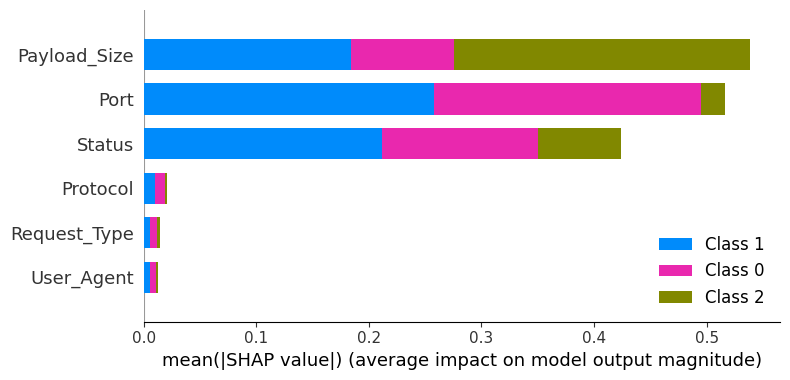

In [10]:
feature_names = list(X.columns)
class_names = list(target_encoder.classes_)  # ['BotAttack', 'Normal', 'PortScan']

# Seleciona amostra de teste para SHAP (max 200)
np.random.seed(42)
sample_idx = np.random.choice(X_test.index, size=min(200, len(X_test)), replace=False)
X_sample = X_test.loc[sample_idx]

# Calcula valores SHAP via TreeExplainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

# Visualiza SHAP summary
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=True)

In [11]:
# ==========================
# SHAP: IMPORTANCIA GLOBAL POR CLASSE
# ==========================
shap_global = {}
for cls_idx, cls_name in enumerate(class_names):
    mean_abs = np.abs(shap_values[:, :, cls_idx]).mean(axis=0)
    shap_global[cls_name] = {feat: round(float(val), 6) for feat, val in zip(feature_names, mean_abs)}

shap_global_json = json.dumps(shap_global, indent=2, ensure_ascii=False)
print("SHAP - Importancia Global por Classe:")
print(shap_global_json)

SHAP - Importancia Global por Classe:
{
  "BotAttack": {
    "Port": 0.236682,
    "Request_Type": 0.006333,
    "Protocol": 0.009255,
    "Payload_Size": 0.091914,
    "User_Agent": 0.005456,
    "Status": 0.138149
  },
  "Normal": {
    "Port": 0.258006,
    "Request_Type": 0.0057,
    "Protocol": 0.01005,
    "Payload_Size": 0.183932,
    "User_Agent": 0.005987,
    "Status": 0.211817
  },
  "PortScan": {
    "Port": 0.021597,
    "Request_Type": 0.002408,
    "Protocol": 0.001272,
    "Payload_Size": 0.262275,
    "User_Agent": 0.001078,
    "Status": 0.073677
  }
}


In [12]:
# ==========================
# SHAP: EXPLICACOES LOCAIS (5 INSTANCIAS)
# ==========================
n_local = 5
shap_local = []
for idx in range(n_local):
    sample_row = X_sample.iloc[idx]
    real_idx = X_sample.index[idx]
    entry = {
        "instance_features": {feat: round(float(sample_row[feat]), 4) for feat in feature_names},
        "true_label": class_names[int(y_test.loc[real_idx])],
        "predicted_label": class_names[int(model.predict(sample_row.to_frame().T)[0])],
        "shap_values_per_class": {}
    }
    for cls_idx, cls_name in enumerate(class_names):
        entry["shap_values_per_class"][cls_name] = {
            feat: round(float(shap_values[idx, f_idx, cls_idx]), 6)
            for f_idx, feat in enumerate(feature_names)
        }
    shap_local.append(entry)

shap_local_json = json.dumps(shap_local, indent=2, ensure_ascii=False)
print("SHAP - Explicacoes Locais (5 instancias):")
print(shap_local_json[:1000], "...")

SHAP - Explicacoes Locais (5 instancias):
[
  {
    "instance_features": {
      "Port": 2.0,
      "Request_Type": 1.0,
      "Protocol": 1.0,
      "Payload_Size": 1.6484,
      "User_Agent": 4.0,
      "Status": 1.0
    },
    "true_label": "BotAttack",
    "predicted_label": "BotAttack",
    "shap_values_per_class": {
      "BotAttack": {
        "Port": 0.06806,
        "Request_Type": -0.004609,
        "Protocol": 0.006065,
        "Payload_Size": 0.583159,
        "User_Agent": -0.024643,
        "Status": -0.111324
      },
      "Normal": {
        "Port": -0.061979,
        "Request_Type": 0.003267,
        "Protocol": -0.007126,
        "Payload_Size": -0.33349,
        "User_Agent": 0.024676,
        "Status": 0.191395
      },
      "PortScan": {
        "Port": -0.006081,
        "Request_Type": 0.001342,
        "Protocol": 0.001061,
        "Payload_Size": -0.249669,
        "User_Agent": -3.3e-05,
        "Status": -0.080071
      }
    }
  },
  {
    "instance_featur

# Explicabilidade LIME

In [13]:
# ==========================
# LIME: EXPLICACOES LOCAIS (mesmas 5 instancias do SHAP)
# ==========================
import warnings

explainer_l = lime_tabular.LimeTabularExplainer(
    X_train.values,
    feature_names=feature_names,
    class_names=class_names,
    mode='classification'
)

lime_explanations = []
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="X does not have valid feature names")
    for idx in range(n_local):
        sample_row = X_sample.iloc[idx]
        real_idx = X_sample.index[idx]

        exp = explainer_l.explain_instance(
            sample_row.values,
            model.predict_proba,
            num_features=6
        )

        lime_explanations.append({
            "instance_index": int(real_idx),
            "true_label": class_names[int(y_test.loc[real_idx])],
            "predicted_label": class_names[int(model.predict(sample_row.to_frame().T)[0])],
            "local_prediction_proba": {
                cls: round(float(p), 4)
                for cls, p in zip(class_names, model.predict_proba(sample_row.to_frame().T)[0])
            },
            "feature_contributions": [
                {"rule": rule, "weight": round(float(w), 6)} for rule, w in exp.as_list()
            ]
        })

lime_explanations_json = json.dumps(lime_explanations, indent=2, ensure_ascii=False)
print("LIME - Explicacoes Locais (5 instancias):")
print(lime_explanations_json[:1000], "...")

LIME - Explicacoes Locais (5 instancias):
[
  {
    "instance_index": 6094,
    "true_label": "BotAttack",
    "predicted_label": "BotAttack",
    "local_prediction_proba": {
      "BotAttack": 0.85,
      "Normal": 0.15,
      "PortScan": 0.0
    },
    "feature_contributions": [
      {
        "rule": "Port <= 3.00",
        "weight": 0.302204
      },
      {
        "rule": "Payload_Size > 0.91",
        "weight": -0.138444
      },
      {
        "rule": "0.00 < Status <= 1.00",
        "weight": 0.114987
      },
      {
        "rule": "Request_Type <= 1.00",
        "weight": 0.005363
      },
      {
        "rule": "0.00 < Protocol <= 1.00",
        "weight": 0.003542
      },
      {
        "rule": "2.00 < User_Agent <= 4.00",
        "weight": 0.002068
      }
    ]
  },
  {
    "instance_index": 8649,
    "true_label": "Normal",
    "predicted_label": "Normal",
    "local_prediction_proba": {
      "BotAttack": 0.0,
      "Normal": 1.0,
      "PortScan": 0.0
    },
    

# Construcao dos Metadados e Prompt para o LLM

In [14]:
# ==========================
# METADADOS DO MODELO E DATASET
# ==========================
column_description = {
    "Port": "Communication port (encoded: 21=0, 22=1, 23=2, 25=3, 53=4, 80=5, 135=6, 443=7, 4444=8, 6667=9, 8080=10, 31337=11)",
    "Request_Type": "Request type (DNS=0, FTP=1, HTTP=2, HTTPS=3, SMTP=4, SSH=5, Telnet=6)",
    "Protocol": "Transport protocol (ICMP=0, TCP=1, UDP=2)",
    "Payload_Size": "Packet payload size (StandardScaler normalized)",
    "User_Agent": "Client agent (Mozilla/5.0=0, Nikto/2.1.6=1, Wget/1.20.3=2, curl/7.68.0=3, nmap/7.80=4, python-requests/2.25.1=5)",
    "Status": "Request status (Failure=0, Success=1)",
    "Scan_Type_Label": "Target variable: BotAttack=0, Normal=1, PortScan=2"
}

model_info = {
    "type": "Random Forest",
    "task": "Network intrusion detection from log entries",
    "target": "Scan_Type_Label",
    "classes": {"BotAttack": 0, "Normal": 1, "PortScan": 2},
    "features": list(X.columns),
    "accuracy": round(float(accuracy_score(y_test, y_pred)), 4)
}

# Samples (20 records)
train_sample = X_train.sample(20, random_state=42)
train_sample["Scan_Type_Label"] = y_train.loc[train_sample.index]
train_sample_json = train_sample.to_json(orient="records")

pred_sample = pd.DataFrame({"real": y_test, "predicted": y_pred})
pred_sample_json = pred_sample.sample(20, random_state=42).to_json(orient="records")

In [15]:
# ==========================
# BUILD MULTI-TURN MESSAGES
# ==========================
system_msg = (
    "You are an expert in Machine Learning, Explainable AI, and Cybersecurity. "
    "You will receive data about an intrusion detection model in multiple messages. "
    "After each message, briefly summarize the key data you received (do NOT analyze yet). "
    "When you receive 'OK, start your analysis.', produce your full structured analysis "
    "using ALL data from ALL previous messages."
)

msg_1_model = f"""I will send you data about a network intrusion detection model in parts.
After each part, briefly summarize what you received. Do NOT analyze yet.

# Part 1: Model Info & Column Descriptions

## Model
{json.dumps(model_info, indent=2, ensure_ascii=False)}

## Column Descriptions (all features are numerically encoded)
{json.dumps(column_description, indent=2, ensure_ascii=False)}"""

msg_2_train = f"""# Part 2: Training Data Sample (25 records)
{train_sample_json}"""

msg_3_pred = f"""# Part 3: Real vs Predicted Labels (25 records)
{pred_sample_json}"""

msg_4_shap_global = f"""# Part 4: SHAP Global Feature Importance — IMPORTANT: remember these exact values

Mean |SHAP| per feature per class, computed over {len(X_sample)} test samples:
{shap_global_json}"""

msg_5_shap_local = f"""# Part 5: SHAP Local Explanations (5 instances)
{shap_local_json}"""

msg_6_lime = f"""# Part 6: LIME Local Explanations (same 5 instances as SHAP)
{lime_explanations_json}"""

msg_7_task = f"""# Part 7: OK, start your analysis.

REMINDER — You received the following data across parts 1-6:
- Part 1: Model info (Random Forest, 3-class intrusion detection) + column descriptions
- Part 2: 25 training records
- Part 3: 25 real vs predicted labels
- Part 4: SHAP global importance per class
- Part 5: SHAP local explanations for 5 instances
- Part 6: LIME local explanations for the same 5 instances

Key SHAP global values (for reference):
{shap_global_json}

Now provide a detailed, structured analysis:

1. **Global Feature Importance (SHAP):** Using the SHAP global values above, interpret the importance ranking for each class (BotAttack, Normal, PortScan). Which features dominate and why from a cybersecurity perspective?

2. **SHAP vs Data Patterns:** Do the SHAP rankings align with patterns in the training/prediction samples?

3. **Local Explanations (SHAP + LIME):** For each of the 5 instances, explain the prediction using both SHAP values AND LIME rules. Where do they agree? Where do they disagree?

4. **Misclassification Analysis:** Identify incorrect predictions and use SHAP/LIME to explain causes.

5. **Cybersecurity Insights:** Strongest indicators of BotAttack vs PortScan. How could a SOC analyst use these?

6. **Model Reliability:** Assess coherence between SHAP, LIME, and data patterns.

7. **Improvement Suggestions:** Concrete improvements based on XAI evidence.

Use numbered sections and subsections."""

conversation_chunks = [
    {"user": msg_1_model},
    {"user": msg_2_train},
    {"user": msg_3_pred},
    {"user": msg_4_shap_global},
    {"user": msg_5_shap_local},
    {"user": msg_6_lime},
    {"user": msg_7_task},
]

n_parts = len(conversation_chunks)
for i, chunk in enumerate(conversation_chunks, 1):
    print(f"Part {i}: {len(chunk['user'])} chars")
total = sum(len(c["user"]) for c in conversation_chunks)
print(f"\nTotal across {n_parts} parts: {total} chars")

Part 1: 1208 chars
Part 2: 2348 chars
Part 3: 549 chars
Part 4: 688 chars
Part 5: 4689 chars
Part 6: 3813 chars
Part 7: 1958 chars

Total across 7 parts: 15253 chars


# Execução: Multi-turn por Modelo Ollama

In [ ]:
# ==========================
# MULTI-TURN LOOP: CADA MODELO RECEBE DADOS EM PARTES
# ==========================
client = OpenAI(
    base_url=OLLAMA_BASE_URL,
    api_key="ollama",
    timeout=httpx.Timeout(REQUEST_TIMEOUT, connect=30.0),
)
results = {}
timings = {}
previous_model = None

for model_cfg in models:
    model_name = model_cfg["name"]
    model_size = model_cfg["size"]

    if previous_model:
        !ollama stop $previous_model
        time.sleep(2)

    print(f"\n{'='*50}")
    print(f"Modelo: {model_name} (tier: {model_size})")
    print(f"{'='*50}")

    messages = [{"role": "system", "content": system_msg}]
    max_tokens_final = 16384 if model_size == "large" else 8192

    t_start = time.time()
    try:
        for i, chunk in enumerate(conversation_chunks):
            is_last = (i == len(conversation_chunks) - 1)
            messages.append({"role": "user", "content": chunk["user"]})

            if not is_last:
                # Let the model summarize what it received (improves retention)
                response = client.chat.completions.create(
                    model=model_name,
                    messages=messages,
                    max_tokens=256
                )
                summary = response.choices[0].message.content.strip()
                messages.append({"role": "assistant", "content": summary})
                print(f"  Part {i+1}/{n_parts} sent -> {summary[:80]}")
            else:
                print(f"  Part {i+1}/{n_parts} sent -> requesting full analysis...")
                response = client.chat.completions.create(
                    model=model_name,
                    messages=messages,
                    max_tokens=max_tokens_final
                )
                result_text = response.choices[0].message.content
                results[model_name] = result_text
                elapsed = time.time() - t_start
                timings[model_name] = elapsed
                print(f"  Done: {len(result_text)} chars em {elapsed:.1f}s")

    except Exception as e:
        elapsed = time.time() - t_start
        timings[model_name] = elapsed
        results[model_name] = f"ERROR: {str(e)}"
        print(f"  Error: {e} ({elapsed:.1f}s)")

    previous_model = model_name

if previous_model:
    !ollama stop $previous_model

print("\nAll models completed.\n")
print("Time per model:")
for name, t in timings.items():
    print(f"  {name}: {t:.1f}s")

# Resultados: Explicações por Modelo com Contexto XAI

In [17]:
# ==========================
# EXIBIÇÃO DOS RESULTADOS
# ==========================
for model_name, result in results.items():
    print(f"\n{'='*60}")
    print(f"MODELO: {model_name}")
    print(f"{'='*60}\n")
    print(result)
    print()


MODELO: gpt-oss:20b

**1. Global Feature Importance (SHAP)**  
*1.1 BotAttack*  
1. **Port (0.2367)** – Highest value; bots typically target a narrow range of privileged ports (80,443, etc.) and the RF model captures this variance.  
2. **Status (0.1381)** – Moderate; many bot‑labeled traffic shows the “SYN”‑only flag (Status ∈ (0, 1]), a hallmark of half‑open connections.  
3. **Payload_Size (0.0919)** – Slightly lower; bots often use small, non‑interactive packets, but payload length is still a distinguishing cue.  
4. **Protocol (0.0093). Request_Type (0.0063). User_Agent (0.0055)** – Very small; in the dataset, these attributes vary mainly within benign flows, offering little discriminatory power for bots.

*Cyber‑security reasoning*: An attacker’s automation tends to reuse the same ports and exploit the same handshake flags, producing a “statistical signature” that SHAP flags as important. The limited influence of protocol/user‑agent reflects that bots frequently disguise themsel

In [ ]:
# ==========================
# SALVAR RESULTADOS EM ARQUIVO JSON
# ==========================
with open("resultados_ollama_llm_xai_shap_lime_multiturn_8.json", "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)
print("Resultados salvos em resultados_ollama_llm_xai_shap_lime_multiturn_8.json")

Resultados salvos em resultados_ollama_llm_xai_shap_lime_multiturn_7.json
